# <h1 align="center">LegalMind — EDA</h1>

**Imports**

In [2]:
from datasets import load_dataset
from collections import Counter
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

**Loading dataset**

In [3]:
ds = load_dataset("coastalcph/lex_glue", "ecthr_a")

**Dataset Structure**

In [4]:
print("Structure of ds:", ds)
print(ds['train'].features)

Structure of ds: DatasetDict({
    train: Dataset({
        features: ['text', 'labels'],
        num_rows: 9000
    })
    test: Dataset({
        features: ['text', 'labels'],
        num_rows: 1000
    })
    validation: Dataset({
        features: ['text', 'labels'],
        num_rows: 1000
    })
})
{'text': List(Value('string')), 'labels': List(ClassLabel(names=['2', '3', '5', '6', '8', '9', '10', '11', '14', 'P1-1']))}


**One record check**

In [5]:
print(ds['train'][0])

{'text': ['11.  At the beginning of the events relevant to the application, K. had a daughter, P., and a son, M., born in 1986 and 1988 respectively. P.’s father is X and M.’s father is V. From March to May 1989 K. was voluntarily hospitalised for about three months, having been diagnosed as suffering from schizophrenia. From August to November 1989 and from December 1989 to March 1990, she was again hospitalised for periods of about three months on account of this illness. In 1991 she was hospitalised for less than a week, diagnosed as suffering from an atypical and undefinable psychosis. It appears that social welfare and health authorities have been in contact with the family since 1989.', '12.  The applicants initially cohabited from the summer of 1991 to July 1993. In 1991 both P. and M. were living with them. From 1991 to 1993 K. and X were involved in a custody and access dispute concerning P. In May 1992 a residence order was made transferring custody of P. to X.', '13.  K. was

**Text Length Analysis**

In [6]:
lengths = [len(case) for case in ds['train']['text']]
print(f"\n=== DŁUGOŚĆ SPRAW ===")
print(f"Średnia: {np.mean(lengths):.1f} paragrafów")
print(f"Min: {min(lengths)}, Max: {max(lengths)}")


=== DŁUGOŚĆ SPRAW ===
Średnia: 23.7 paragrafów
Min: 1, Max: 558


**Text Length Analysis - Visualization**

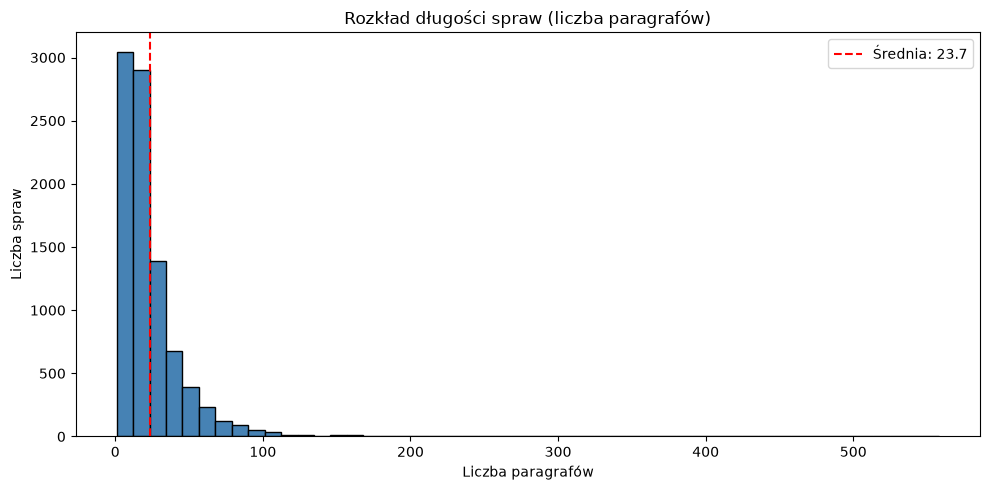

In [7]:
lengths = [len(case) for case in ds['train']['text']]

plt.figure(figsize=(10,5))
plt.hist(lengths, bins=50, color='steelblue', edgecolor='black')
plt.title('Rozkład długości spraw (liczba paragrafów)')
plt.xlabel('Liczba paragrafów')
plt.ylabel('Liczba spraw')
plt.axvline(np.mean(lengths), color='red', linestyle='--', label=f'Średnia: {np.mean(lengths):.1f}')
plt.legend()
plt.tight_layout()
plt.show()

**Article Distribution**

In [8]:
all_labels = [l for case in ds['train']['labels'] for l in case]
counter = Counter(all_labels)
articles = ['2','3','5','6','8','9','10','11','14','P1-1']
print("=== ROZKŁAD ARTYKUŁÓW ===")
for idx, count in sorted(counter.items()):
    print(f"Artykuł {articles[idx]}: {count} przypadków")

=== ROZKŁAD ARTYKUŁÓW ===
Artykuł 2: 505 przypadków
Artykuł 3: 1349 przypadków
Artykuł 5: 1368 przypadków
Artykuł 6: 4704 przypadków
Artykuł 8: 710 przypadków
Artykuł 9: 41 przypadków
Artykuł 10: 291 przypadków
Artykuł 11: 110 przypadków
Artykuł 14: 141 przypadków
Artykuł P1-1: 1421 przypadków


**Article Distribution - Visualization**

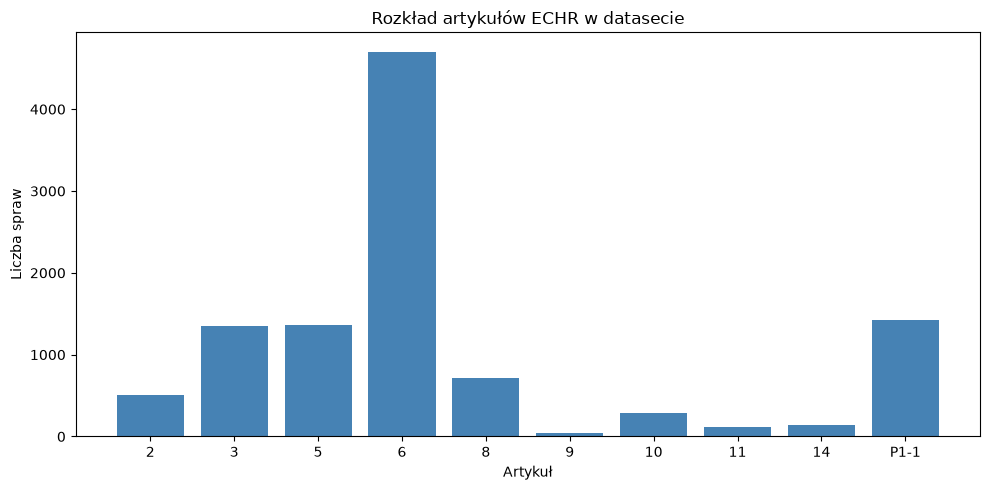

In [9]:
articles = ['2','3','5','6','8','9','10','11','14','P1-1']

# === WIZUALIZACJA 1: Rozkład artykułów ===
all_labels = [l for case in ds['train']['labels'] for l in case]
counter = Counter(all_labels)
counts = [counter[i] for i in range(len(articles))]

plt.figure(figsize=(10,5))
plt.bar(articles, counts, color='steelblue')
plt.title('Rozkład artykułów ECHR w datasecie')
plt.xlabel('Artykuł')
plt.ylabel('Liczba spraw')
plt.tight_layout()
plt.show()

**Multi-label Analysis**

In [10]:
multi = [len(l) for l in ds['train']['labels']]
print(f"\n=== LICZBA NARUSZEŃ NA SPRAWĘ ===")
print(f"Średnia: {np.mean(multi):.1f}")
print(f"Tylko 1 naruszenie: {sum(1 for x in multi if x==1)}")
print(f"2+ naruszeń: {sum(1 for x in multi if x>1)}")


=== LICZBA NARUSZEŃ NA SPRAWĘ ===
Średnia: 1.2
Tylko 1 naruszenie: 5924
2+ naruszeń: 2162


**Co-occurrence Analysis**

In [11]:
pairs = Counter()
for labels in ds['train']['labels']:
    if len(labels) > 1:
        for i in range(len(labels)):
            for j in range(i+1, len(labels)):
                pairs[(labels[i], labels[j])] += 1
print("=== TOP CO-OCCURRENCE ===")
articles = ['2','3','5','6','8','9','10','11','14','P1-1']
for (a,b), count in pairs.most_common(5):
    print(f"Art.{articles[a]} + Art.{articles[b]}: {count}x")


=== TOP CO-OCCURRENCE ===
Art.6 + Art.P1-1: 958x
Art.3 + Art.5: 454x
Art.5 + Art.6: 259x
Art.2 + Art.3: 222x
Art.2 + Art.5: 199x


**Co-occurance Visualization**

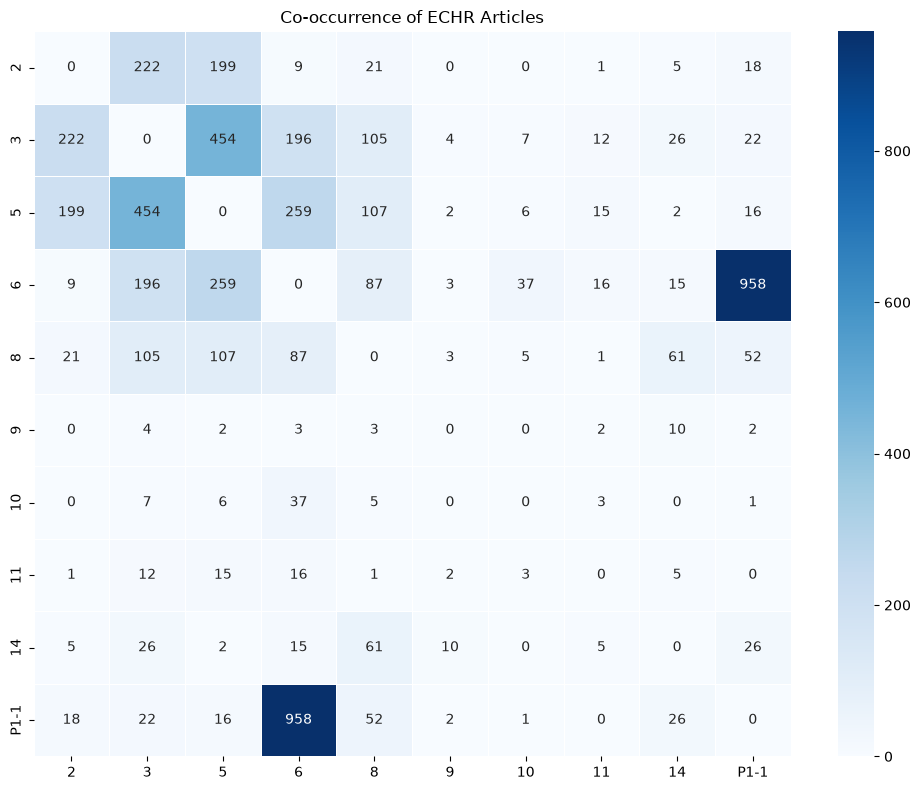

In [12]:
articles = ['2','3','5','6','8','9','10','11','14','P1-1']
n = len(articles)
matrix = np.zeros((n, n))

for (a, b), count in pairs.items():
    matrix[a][b] = count
    matrix[b][a] = count

plt.figure(figsize=(10, 8))
sns.heatmap(
    matrix,
    xticklabels=articles,
    yticklabels=articles,
    annot=True,
    fmt='.0f',
    cmap='Blues',
    linewidths=0.5
)
plt.title('Co-occurrence of ECHR Articles')
plt.tight_layout()
plt.show()

**Outliers**

In [13]:
lengths = [len(case) for case in ds['train']['text']]
long = sum(1 for l in lengths if l > 50)
print(f"=== DŁUGIE SPRAWY (>50 paragrafów) ===")
print(f"{long} spraw ({long/len(lengths)*100:.1f}%) wymaga truncation")
short = sum(1 for l in lengths if l < 3)
print(f"\n=== BARDZO KRÓTKIE (<3 paragrafy) ===")
print(f"{short} spraw - potencjalnie problematyczne")

=== DŁUGIE SPRAWY (>50 paragrafów) ===
791 spraw (8.8%) wymaga truncation

=== BARDZO KRÓTKIE (<3 paragrafy) ===
3 spraw - potencjalnie problematyczne


**Outliers Visualization**

/var/folders/w6/7c1bl_mx43s4t5d9ndx4b_h80000gn/T/ipykernel_2127/1573865836.py:2: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(lengths, vert=False)


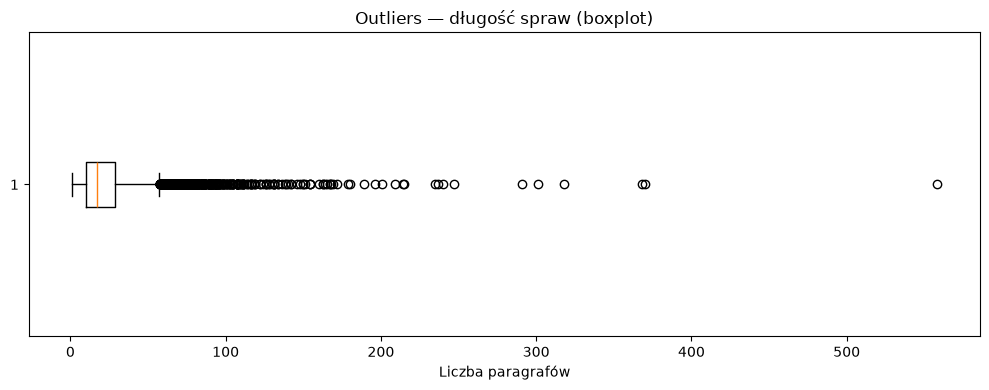

In [14]:
plt.figure(figsize=(10, 4))
plt.boxplot(lengths, vert=False)
plt.xlabel('Liczba paragrafów')
plt.title('Outliers — długość spraw (boxplot)')
plt.tight_layout()
plt.show()

**Bias Analysis**

In [15]:
print("=== ANALIZA BIASU ===")
print(f"Dominujący artykuł: Art. 6 ({counter[3]} przypadków)")
print(f"Najmniej danych: Art. 9 ({counter[5]} przypadków)")
print(f"Stosunek: {counter[3]/counter[5]:.0f}x więcej Art. 6 niż Art. 9")
print("UWAGA: Model może być biased w stronę Art. 6")

=== ANALIZA BIASU ===
Dominujący artykuł: Art. 6 (4704 przypadków)
Najmniej danych: Art. 9 (41 przypadków)
Stosunek: 115x więcej Art. 6 niż Art. 9
UWAGA: Model może być biased w stronę Art. 6


**Bias Analysis - Visualization**

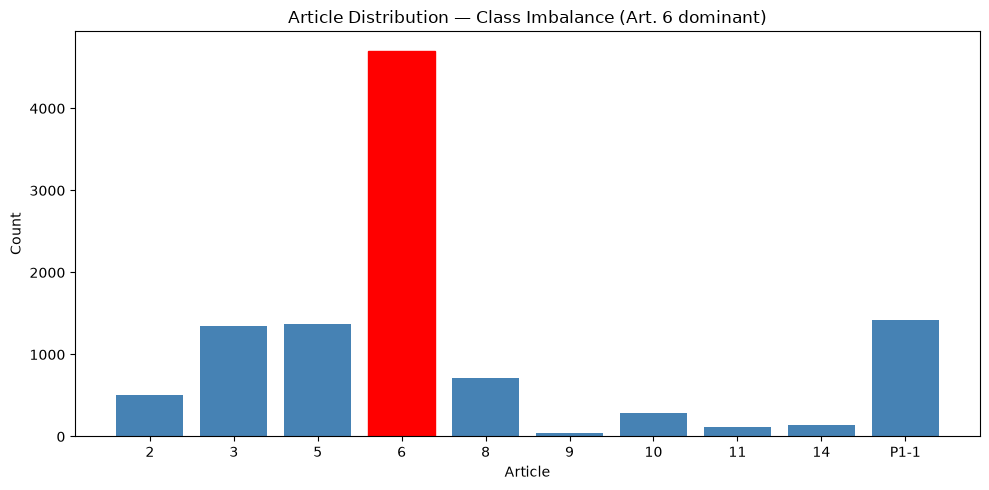

In [16]:
articles = ['2','3','5','6','8','9','10','11','14','P1-1']
counts = [counter[i] for i in range(len(articles))]

plt.figure(figsize=(10,5))
bars = plt.bar(articles, counts, color='steelblue')
bars[3].set_color('red')  # Art. 6 = index 3
plt.title('Article Distribution — Class Imbalance (Art. 6 dominant)')
plt.xlabel('Article')
plt.ylabel('Count')
plt.tight_layout()
plt.show()